In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("/content/titanic.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df= df[['Survived','Pclass','Sex','Age','SibSp','Parch','Ticket','Fare','Cabin','Embarked']]
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687
Embarked,2


In [ ]:
df['Age'].fillna(df['Age'].median(),inplace=True)

/tmp/ipykernel_624/1527141296.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)


In [ ]:
df.drop(columns=['Cabin'],inplace=True)

In [ ]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace= True)

/tmp/ipykernel_624/1843428846.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0],inplace= True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    object 
 7   Fare      891 non-null    float64
 8   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [ ]:
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
df['Ticket']=le.fit_transform(df['Ticket'])
df['Embarked']=le.fit_transform(df['Embarked'])

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,1,22.0,1,0,523,7.2500,2
1,1,1,0,38.0,1,0,596,71.2833,0
2,1,3,0,26.0,0,0,669,7.9250,2
3,1,1,0,35.0,1,0,49,53.1000,2
4,0,3,1,35.0,0,0,472,8.0500,2


In [ ]:
x= df.drop('Survived',axis=1)
y= df['Survived']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
depth_values = [2,4,6,8]
criteria = ['gini', 'entropy']
results =[]
for c in criteria:
  for d in depth_values:
    model = DecisionTreeClassifier(max_depth=d,criterion=c, random_state=42)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm=confusion_matrix(y_test, y_pred)
    results.append((c,d,accuracy,f1))
    print("Criteria:",c)
    print("Max depth",d)
    print("Accuracy:",accuracy)
    print("F1 Score:",f1)
    print("Confusion matrix",cm)
    print()


Criteria: gini
Max depth 2
Accuracy: 0.7723880597014925
F1 Score: 0.6514285714285715
Confusion matrix [[150   7]
 [ 54  57]]

Criteria: gini
Max depth 4
Accuracy: 0.7873134328358209
F1 Score: 0.7135678391959799
Confusion matrix [[140  17]
 [ 40  71]]

Criteria: gini
Max depth 6
Accuracy: 0.746268656716418
F1 Score: 0.6822429906542056
Confusion matrix [[127  30]
 [ 38  73]]

Criteria: gini
Max depth 8
Accuracy: 0.7201492537313433
F1 Score: 0.6511627906976745
Confusion matrix [[123  34]
 [ 41  70]]

Criteria: entropy
Max depth 2
Accuracy: 0.7723880597014925
F1 Score: 0.6514285714285715
Confusion matrix [[150   7]
 [ 54  57]]

Criteria: entropy
Max depth 4
Accuracy: 0.8097014925373134
F1 Score: 0.7605633802816901
Confusion matrix [[136  21]
 [ 30  81]]

Criteria: entropy
Max depth 6
Accuracy: 0.753731343283582
F1 Score: 0.7105263157894737
Confusion matrix [[121  36]
 [ 30  81]]

Criteria: entropy
Max depth 8
Accuracy: 0.7425373134328358
F1 Score: 0.6790697674418604
Confusion matrix [[126 

In [ ]:
results_df = pd.DataFrame(results, columns=['Criteria', 'Max Depth', 'Accuracy', 'F1 Score'])
results_df

,Criteria,Max Depth,Accuracy,F1 Score
0,gini,2,0.772388,0.651429
1,gini,4,0.787313,0.713568
2,gini,6,0.746269,0.682243
3,gini,8,0.720149,0.651163
4,entropy,2,0.772388,0.651429
5,entropy,4,0.809701,0.760563
6,entropy,6,0.753731,0.710526
7,entropy,8,0.742537,0.679070


In [ ]:
results_df.sort_values(by='F1 Score', ascending=False)


,Criteria,Max Depth,Accuracy,F1 Score
5,entropy,4,0.809701,0.760563
1,gini,4,0.787313,0.713568
6,entropy,6,0.753731,0.710526
2,gini,6,0.746269,0.682243
7,entropy,8,0.742537,0.679070
0,gini,2,0.772388,0.651429
4,entropy,2,0.772388,0.651429
3,gini,8,0.720149,0.651163


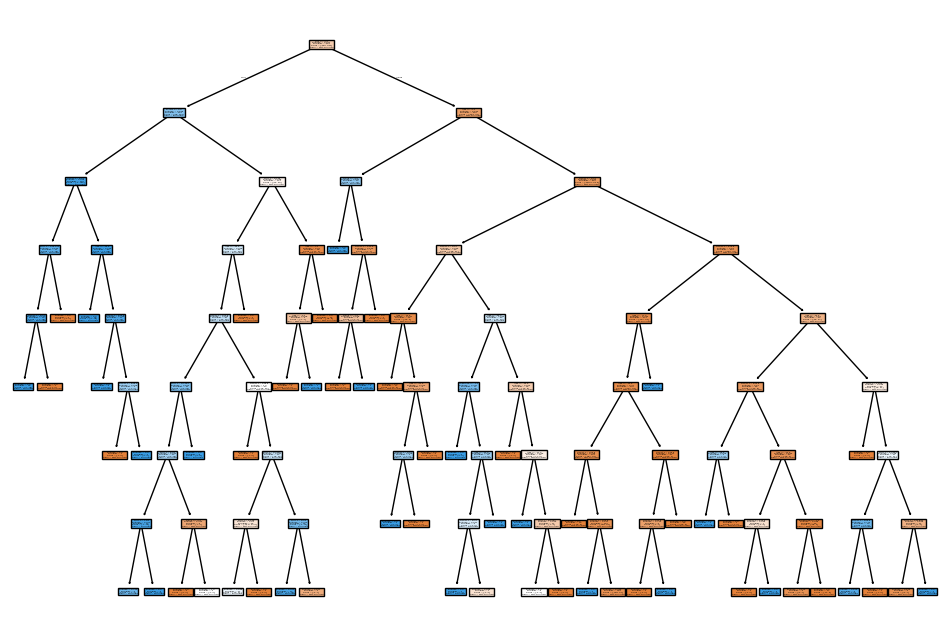

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plot_tree(model,feature_names=x.columns,class_names=['Not Survived','Survived'],filled=True)
plt.show()